In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
import random
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


### Load Data

Load the survey dataset and prepare features and targets. 

The goal is to predict PHQ-9 outcomes: either as a binary classification (PHQ9 >= 10) or as a continuous regression (PHQ9 total score). Features include Q4-Q34 responses and Age. The dataset is split into training and test sets to evaluate model performance on unseen data.

In [15]:
df = pd.read_csv("../data/DSA4262_Survey_Cleaned.csv")

### Feature Selection

In [3]:
# Demographics
demographics = ["Q1_Age"]  # numeric

# Smartphone usage behaviour (ordinal / Likert) Q4-Q34 and age
usage_num_cols = [
    "Q1_Age", "Q4_DailyPhoneTime_num", "Q5_CheckFrequency_num", "Q6_AfterWakeCheck_num",
    "Q7_After11PMUse_num", "Q8_StopUseAtNight_num", "Q10_SocialMediaTime_num",
    "Q11_PhoneDuringMeals_num", "Q12_PhoneDuringWorkClass_num", "Q13_CheckDuringTasks_num",
    "Q14_NotificationsInterrupt_num", "Q15_UseWhenBored_num", "Q16_UseWhenStressed_num",
    "Q17_DistractNegativeEmotions_num", "Q18_PhoneInBed_num", "Q19_PhoneDelaysSleep_num",
    "Q20_NotificationsWakeNight_num", "Q21_WakeToCheckPhone_num", "Q22_UnlockWithoutReason_num",
    "Q23_UseLongerThanIntended_A_num", "Q24_FailToReduceUse_num",
    "Q25_MissPlannedWork_num", "Q26_ConcentrationProblems_num", "Q27_PhysicalPain_num",
    "Q28_CannotStandWithoutPhone_num", "Q29_ImpatientWithoutPhone_num", "Q30_PhoneOnMyMind_num",
    "Q31_WontGiveUpPhone_num", "Q32_ConstantChecking_num", "Q33_UseLongerThanIntended_B_num",
    "Q34_OthersSayTooMuchUse_num"
]

# One-hot encoded demographics
onehot_cols = [col for col in df.columns if col.startswith("Q2_") or col.startswith("Q3_")]

# App usage binary columns
app_usage_cols = [
    "Q9_App_SocialMedia", "Q9_App_Messaging", "Q9_App_ProductivityStudy",
    "Q9_App_WebBrowsing", "Q9_App_VideoStreaming", "Q9_App_Gaming", "Q9_App_Shopping"
]

# Combine all feature columns
feature_cols = demographics + usage_num_cols + onehot_cols + app_usage_cols

### Prepare Train and Test Set

In [4]:
X = df[feature_cols]

# Classification target
y_class = df["PHQ9_10plus"]

# Regression target
y_reg = df["PHQ9_Total"]

# Classification
X_train, X_test, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

# Regression
_, _, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print("Feature columns used for modeling:", len(feature_cols))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Feature columns used for modeling: 46
X_train shape: (40, 46)
X_test shape: (10, 46)


### Expand dataset size

To improve model training and reduce overfitting, we expand the dataset size artificially. This helps provide more samples for both classification and regression tasks, allowing models to learn more robust patterns from the survey responses.

In [5]:
target_size = 500
current_size = X.shape[0]

if current_size < target_size:
    n_to_add = target_size - current_size
    
    # sample with replacement
    df_synthetic = df.sample(n=n_to_add, replace=True, random_state=42).copy()
    
    # small perturbation for numeric features
    for col in usage_num_cols + ["Q1_Age"]:
        df_synthetic[col] = df_synthetic[col].apply(lambda x: max(0, min(x + random.choice([-1,0,1]), 10)))
    
    # combine original and synthetic
    df = pd.concat([df, df_synthetic], ignore_index=True)
    
    # recompute features and targets
    X = df[feature_cols]
    y_class = df["PHQ9_10plus"]
    y_reg = df["PHQ9_Total"]
    
    # train/test split
    X_train, X_test, y_train_class, y_test_class = train_test_split(
        X, y_class, test_size=0.2, random_state=42
    )
    _, _, y_train_reg, y_test_reg = train_test_split(
        X, y_reg, test_size=0.2, random_state=42
    )

print("Expanded dataset size:", df.shape)

Expanded dataset size: (500, 97)


## Task 1: Binary Classification

Binary classification aims to predict whether a participant has PHQ9 score >= 10. 

Logistic Regression is used as a simple linear model to capture general trends. 

Random Forest is used as a non-linear ensemble method to capture more complex patterns. Using both methods allows comparison between linear and non-linear approaches.

### Logistic Regression

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Train model
logreg.fit(X_train, y_train_class)

# Predict on test set
y_pred_class = logreg.predict(X_test)

# ===================== Evaluate =====================
acc = accuracy_score(y_test_class, y_pred_class)
print("Logistic Regression Test Accuracy:", acc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_class))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_class))

Logistic Regression Test Accuracy: 0.81

Confusion Matrix:
[[66  8]
 [11 15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87        74
           1       0.65      0.58      0.61        26

    accuracy                           0.81       100
   macro avg       0.75      0.73      0.74       100
weighted avg       0.80      0.81      0.81       100



## Random Forest

In [7]:
# Initialize model
rf_clf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced'
)

# Train model
rf_clf.fit(X_train, y_train_class)

# Predict on test set
y_pred_rf = rf_clf.predict(X_test)

# ===================== Evaluation =====================
acc_rf = accuracy_score(y_test_class, y_pred_rf)
print("Random Forest Test Accuracy:", acc_rf)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_rf, zero_division=0))

Random Forest Test Accuracy: 0.93

Confusion Matrix:
[[74  0]
 [ 7 19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        74
           1       1.00      0.73      0.84        26

    accuracy                           0.93       100
   macro avg       0.96      0.87      0.90       100
weighted avg       0.94      0.93      0.93       100



## Summary of Task 1

Logistic Regression achieved 81% accuracy. Most high-PHQ9 cases (>=10) were predicted correctly, but some were misclassified as low-PHQ9. Random Forest improved accuracy to 93%, capturing almost all low-PHQ9 cases correctly. Some high-PHQ9 cases were still misclassified as low, but overall prediction improved significantly. This suggests Random Forest can better model complex patterns in survey responses compared to linear methods.

## Task 2: Regression

Regression aims to predict the continuous PHQ9 total score based on smartphone usage features and age. We use two methods: Linear Regression and Random Forest Regression. 

Linear Regression is simple and interpretable, but assumes a linear relationship between features and the target, which may limit its performance. Random Forest Regression can capture non-linear patterns and interactions between features, making it more flexible, but less interpretable.

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

## Linear Regression

Linear Regression MSE: 10.322492155350817
Linear Regression R2: 0.4792380066819619


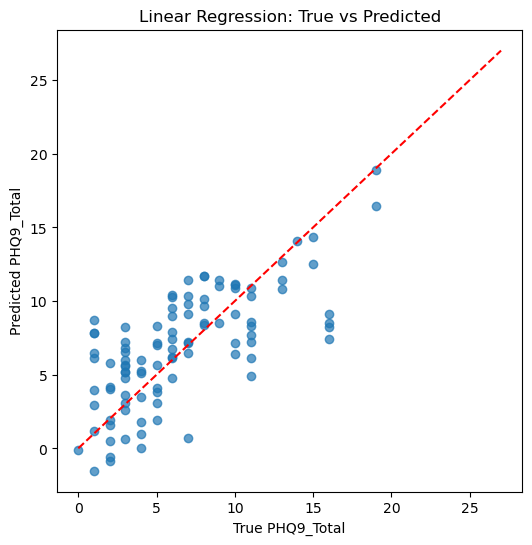

In [9]:
linreg = LinearRegression()
linreg.fit(X_train, y_train_reg)
y_pred_lin = linreg.predict(X_test)

# Evaluate
mse_lin = mean_squared_error(y_test_reg, y_pred_lin)
r2_lin = r2_score(y_test_reg, y_pred_lin)
print("Linear Regression MSE:", mse_lin)
print("Linear Regression R2:", r2_lin)

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_lin, alpha=0.7)
plt.plot([0,27],[0,27], 'r--')  # y=x line
plt.xlabel("True PHQ9_Total")
plt.ylabel("Predicted PHQ9_Total")
plt.title("Linear Regression: True vs Predicted")
plt.show()

## Random Forest Regression

Random Forest Regression MSE: 6.057714000000001
Random Forest Regression R2: 0.6943928684939384


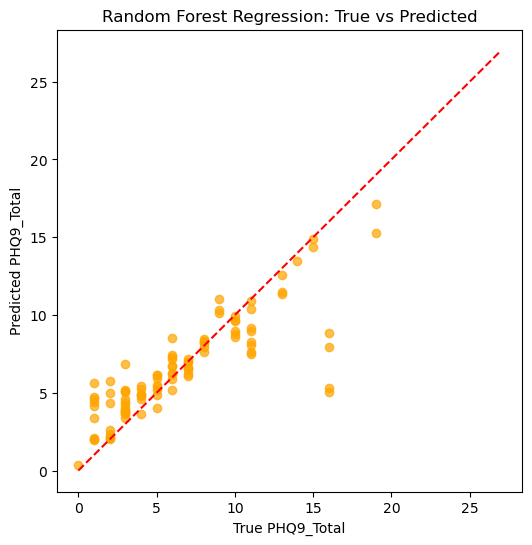

In [10]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test)

# Evaluate
mse_rf = mean_squared_error(y_test_reg, y_pred_rf_reg)
r2_rf = r2_score(y_test_reg, y_pred_rf_reg)
print("Random Forest Regression MSE:", mse_rf)
print("Random Forest Regression R2:", r2_rf)

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_rf_reg, alpha=0.7, color='orange')
plt.plot([0,27],[0,27], 'r--')  # y=x line
plt.xlabel("True PHQ9_Total")
plt.ylabel("Predicted PHQ9_Total")
plt.title("Random Forest Regression: True vs Predicted")
plt.show()

## Summary of Task 2

Compared to Linear Regression, Random Forest produces predictions that are much closer to the ideal y=x reference line in the true vs predicted plots. Most points lie close to the line, indicating better prediction accuracy. 

However, a few high PHQ9 cases (above 15) are still underestimated, which is consistent with the earlier classification task where high-risk cases were harder to predict. This may be due to limited samples in the high PHQ9 range. From a quantitative perspective, MSE decreases from 10.32 to 6.06 and R² improves from 0.479 to 0.694, both indicating that Random Forest provides a better fit to the data.

## Unsupervised Learning

In this section, we explore the underlying structure of the dataset without using labels. We first apply PCA to reduce high-dimensional survey features into two dimensions for visualization. This helps reveal general data distribution patterns. Then, we apply K-Means clustering with k=2, 3, and 4 to group participants based on their smartphone usage behaviors. The goal is to identify meaningful user segments and compare their differences.

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
unsupervised_cols = [
    "Q1_Age",
    "Q4_DailyPhoneTime_num", "Q5_CheckFrequency_num", "Q6_AfterWakeCheck_num",
    "Q7_After11PMUse_num", "Q8_StopUseAtNight_num", "Q10_SocialMediaTime_num",
    "Q11_PhoneDuringMeals_num", "Q12_PhoneDuringWorkClass_num", "Q13_CheckDuringTasks_num",
    "Q14_NotificationsInterrupt_num", "Q15_UseWhenBored_num", "Q16_UseWhenStressed_num",
    "Q17_DistractNegativeEmotions_num", "Q18_PhoneInBed_num", "Q19_PhoneDelaysSleep_num",
    "Q20_NotificationsWakeNight_num", "Q21_WakeToCheckPhone_num", "Q22_UnlockWithoutReason_num",
    "Q23_UseLongerThanIntended_A_num", "Q24_FailToReduceUse_num",
    "Q25_MissPlannedWork_num", "Q26_ConcentrationProblems_num", "Q27_PhysicalPain_num",
    "Q28_CannotStandWithoutPhone_num", "Q29_ImpatientWithoutPhone_num",
    "Q30_PhoneOnMyMind_num", "Q31_WontGiveUpPhone_num", "Q32_ConstantChecking_num",
    "Q33_UseLongerThanIntended_B_num", "Q34_OthersSayTooMuchUse_num"
]

X_unsupervised = df[unsupervised_cols].fillna(0)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsupervised)

### PCA

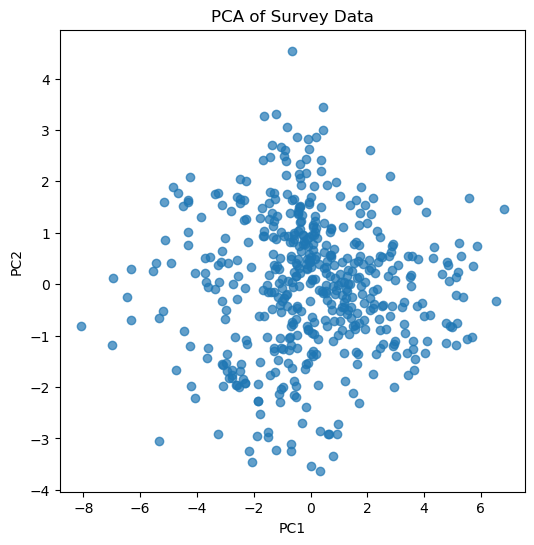

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Survey Data")
plt.show()

### K-means Clustering

c:\Users\User\miniconda3\envs\charllm-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


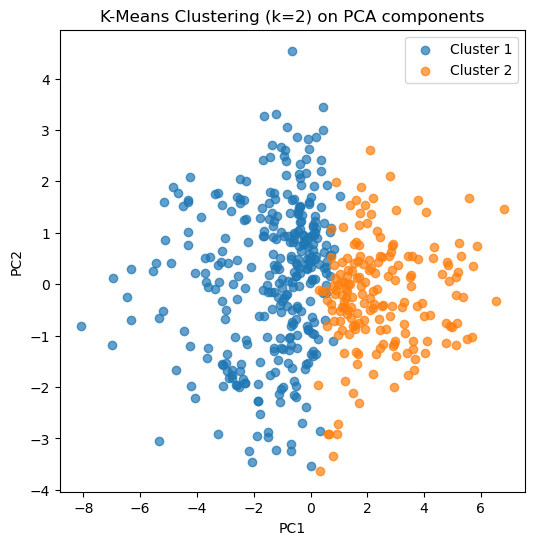

c:\Users\User\miniconda3\envs\charllm-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


K=2 cluster PHQ9_Total averages:
Cluster
0    5.940810
1    9.050279
Name: PHQ9_Total, dtype: float64
----------------------------------------


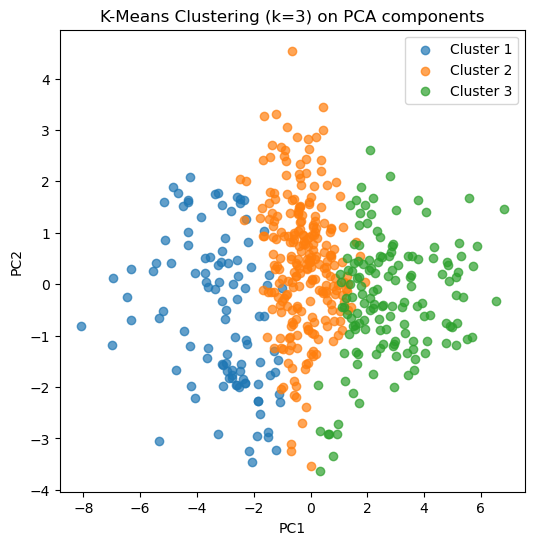

K=3 cluster PHQ9_Total averages:
Cluster
0    4.915888
1    6.685484
2    9.262069
Name: PHQ9_Total, dtype: float64
----------------------------------------


c:\Users\User\miniconda3\envs\charllm-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


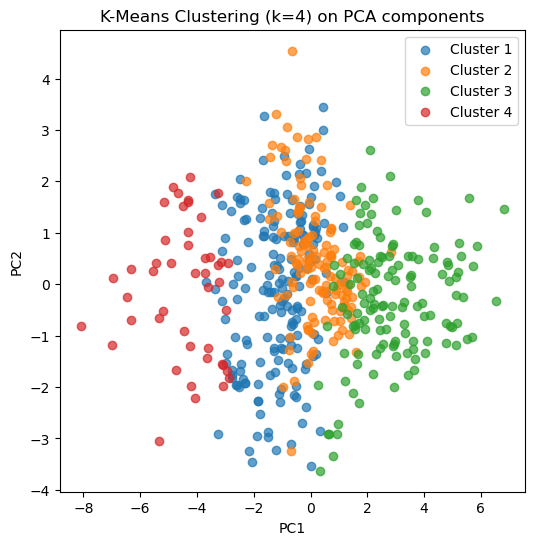

K=4 cluster PHQ9_Total averages:
Cluster
0    5.972973
1    6.096296
2    9.865672
3    6.021739
Name: PHQ9_Total, dtype: float64
----------------------------------------


In [14]:
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    # Scatter plot with clusters
    plt.figure(figsize=(6,6))
    for cluster in range(k):
        plt.scatter(
            X_pca[labels==cluster, 0],
            X_pca[labels==cluster, 1],
            alpha=0.7,
            label=f"Cluster {cluster+1}"
        )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"K-Means Clustering (k={k}) on PCA components")
    plt.legend()
    plt.show()
    
    # PHQ9_Total mean per cluster
    df["Cluster"] = labels
    cluster_phq_mean = df.groupby("Cluster")["PHQ9_Total"].mean()
    print(f"K={k} cluster PHQ9_Total averages:")
    print(cluster_phq_mean)
    print("-"*40)

## Summary of Unsupervised Learning

Using k=2 results in clusters that are too coarse and fail to capture detailed differences between users. Using k=4 leads to significant overlap between clusters, making the separation less clear. In comparison, k=3 provides a good balance, offering more detailed grouping while maintaining relatively clear separation. This suggests that three clusters best represent the underlying structure of the dataset.

# From Models to Digital Wellbeing Intervention

This project is motivated by the challenge that university students often struggle to recognize unhealthy smartphone usage patterns, which may gradually contribute to increased levels of depression. Our goal is to support a digital wellbeing application that can identify such patterns early and provide timely, non-intrusive interventions.

In this study, we use survey-based behavioral data as a proxy for smartphone usage signals. Features such as daily usage time, late-night activity, frequency of checking, and emotional dependence are transformed into structured numerical inputs. In a real-world application, these features can be automatically extracted from smartphone logs, including screen time statistics, app usage categories, notification frequency, and usage patterns across different times of the day.

The supervised learning tasks provide the core predictive capability of the system. The binary classification model enables the app to flag whether a user is at risk (PHQ9 ≥ 10), which can trigger lightweight interventions such as reminders or usage insights. The regression model goes a step further by estimating the user’s PHQ-9 score, allowing for more personalized feedback and severity-aware recommendations. The strong performance of Random Forest in both tasks suggests that non-linear behavioral patterns are important in identifying mental health risks.

The unsupervised learning component complements this by uncovering natural groupings of user behavior. By clustering users into segments (e.g., low-risk, moderate-risk, high-risk usage patterns), the app can tailor different strategies for each group. For example, users in high-risk clusters may benefit from stricter usage nudges, while low-risk users may only need periodic awareness prompts. The clustering results also help validate that meaningful behavioral patterns exist beyond labeled outcomes.

Overall, this pipeline demonstrates how raw behavioral data can be transformed into actionable insights. By combining feature extraction, predictive modeling, and behavioral segmentation, the system provides a foundation for a digital wellbeing application that can monitor usage patterns, assess risk, and deliver personalized interventions. Importantly, this approach aligns with the goal of supporting users in a subtle and non-judgmental way, enabling healthier smartphone habits without intrusive monitoring.